# Predição de λmax de Moléculas Orgânicas via Aprendizado Profundo
### CCM-109 — Tópicos Especiais em Inteligência Artificial (UFABC) — Crhisângela Ferreira

Notebook de experimentos do projeto final. Implementa o protocolo descrito na proposta e no
relatório (`latex/relatorio_lambda_max_SBC.pdf`), incorporando as recomendações do professor:

- **Etapa 1** — treino e comparação, sobre o [Deep4Chem](https://doi.org/10.6084/m9.figshare.12045567.v2)
  (Joung et al., 2020), de:
  - Baseline 1: MLP + fingerprints Morgan;
  - Baseline 2 (forte): Gradient Boosting sobre descritores RDKit;
  - Modelo principal: Bi-LSTM char-level sobre SMILES;
  - Extensão opcional de estado da arte: D-MPNN (Chemprop).
  - SMILES do solvente incluído como feature em **todos** os modelos (λmax é solvatocrômico).
  - **Scaffold split** (Bemis-Murcko), não aleatório, e validação cruzada por grupo de scaffold
    para seleção de hiperparâmetros.
  - Métricas: **MAE** e **RMSE** (nm).
- **Etapa 2** — aplicação do melhor modelo da Etapa 1 ao conjunto proprietário de 5.974 moléculas
  (`resources/banco_smiles_aromatizados.parquet`, sem rótulo), com **quantificação de incerteza**
  (MC-Dropout para redes neurais, ensemble bootstrap para Gradient Boosting) para priorizar
  candidatos de alta confiança para síntese, e uma **análise de deslocamento de distribuição**
  (domain shift) entre o Deep4Chem e o conjunto proprietário.

> **Como usar:** rode as células em ordem. O flag `QUICK_TEST` abaixo controla o tamanho dos
> experimentos — deixe `True` para validar rapidamente o pipeline (CPU, poucos minutos) e mude
> para `False` no Google Colab (GPU) para o treino completo que deve alimentar o relatório final.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from scipy.stats import ks_2samp

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

RDLogger.DisableLog("rdApp.*")   # silencia avisos de parsing/kekulização do RDKit
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
QUICK_TEST = True

N_SUBSAMPLE = 1500 if QUICK_TEST else None   # None = usa o Deep4Chem inteiro
CV_FOLDS = 3                                  # folds da validação cruzada por scaffold
EPOCHS_CV = 5 if QUICK_TEST else 15           # épocas usadas durante a busca de hiperparâmetros
EPOCHS_MLP = 15 if QUICK_TEST else 100        # épocas do treino final do MLP
EPOCHS_BILSTM = 8 if QUICK_TEST else 40       # épocas do treino final da Bi-LSTM
GBM_N_ESTIMATORS = 100 if QUICK_TEST else 500
MC_PASSES = 10 if QUICK_TEST else 30          # passadas de MC-Dropout / ensemble na Etapa 2
GBM_ENSEMBLE_SIZE = 5                         # nº de GBMs no ensemble bootstrap (incerteza)

DATA_DIR = "../resources/deep4chem_raw"       # cache local do Deep4Chem
PROP_PATH = "../resources/banco_smiles_aromatizados.parquet"
FIG_DIR = "../resources/figures"              # figuras exportadas para o relatório LaTeX
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("QUICK_TEST =", QUICK_TEST)

QUICK_TEST = True


## 1. Dados — Deep4Chem

Base pública de propriedades ópticas experimentais de cromóforos orgânicos (Joung et al., 2020),
disponível via Figshare (DOI: `10.6084/m9.figshare.12045567.v2`)


In [ ]:
df_raw = pd.read_csv('resources\DB for chromophore_Sci_Data_rev02.csv')
print(df_raw.shape)
df_raw.head(3)

Usando cache local: ../resources/deep4chem_raw\DB for chromophore_Sci_Data_rev02.csv
(20236, 14)


,Tag,Chromophore,Solvent,Absorption max (nm),Emission max (nm),Lifetime (ns),Quantum yield,log(e/mol-1 dm3 cm-1),abs FWHM (cm-1),emi FWHM (cm-1),abs FWHM (nm),emi FWHM (nm),Molecular weight (g mol-1),Reference
0,1,N#Cc1cc2ccc(O)cc2oc1=O,O,355.0,410.0,2.804262,NaN,NaN,NaN,NaN,NaN,NaN,187.15370,DOI: 10.1021/acs.jpcb.5b09905
1,2,N#Cc1cc2ccc([O-])cc2oc1=O,O,408.0,450.0,3.961965,NaN,NaN,NaN,NaN,NaN,43.0,186.14576,DOI: 10.1021/acs.jpcb.5b09905
2,3,CCCCCCCCCCCC#CC#CCCCCCCCCCN1C(=O)c2ccc3c4ccc5c...,ClC(Cl)Cl,526.0,535.0,3.602954,NaN,NaN,NaN,NaN,NaN,NaN,1061.54348,https://doi.org/10.1002/smll.201901342


In [ ]:
COL_MAP = {
    "Chromophore": "smiles",
    "Solvent": "solvent_smiles",
    "Absorption max (nm)": "lambda_max",
}
df = df_raw.rename(columns=COL_MAP)[list(COL_MAP.values())].dropna().reset_index(drop=True)


def valid_smiles(s):
    return Chem.MolFromSmiles(s) is not None


mask_valid = df["smiles"].apply(valid_smiles) & df["solvent_smiles"].apply(valid_smiles)
df = df[mask_valid].drop_duplicates(subset=["smiles", "solvent_smiles"]).reset_index(drop=True)

if N_SUBSAMPLE is not None and len(df) > N_SUBSAMPLE:
    df = df.sample(n=N_SUBSAMPLE, random_state=SEED).reset_index(drop=True)

print(len(df), "registros válidos (cromóforo + solvente parseáveis pelo RDKit)")
df.head()

1500 registros válidos (cromóforo + solvente parseáveis pelo RDKit)


,smiles,solvent_smiles,lambda_max
0,CC/[NH+]=c1\cc2oc3cc(NCCC(=O)NC(CCC(=O)OC)C(=O...,CCO,600.0
1,NNC(=O)c1ccc(/C=C/c2ccc(C(=O)NN)cc2)cc1,CN(C)C=O,333.0
2,CN(CCO)c1ccc(/C=C/C2=C(C#N)C(C(C#N)C#N)OC2(C)C...,CS(C)=O,595.0
3,F[B-]1(F)Oc2ccccc2-c2nc(-c3ccccc3)c3cc(Cl)ccc3...,Cc1ccccc1,395.0
4,N#Cc1nc2cnc(N)nc2n1Cc1ccccc1,O,331.0


### 1.1. Panorama do dataset

Distribuição de λmax e solventes mais frequentes — útil para a Seção "Descrição do Problema"/
"Resultados" do relatório.

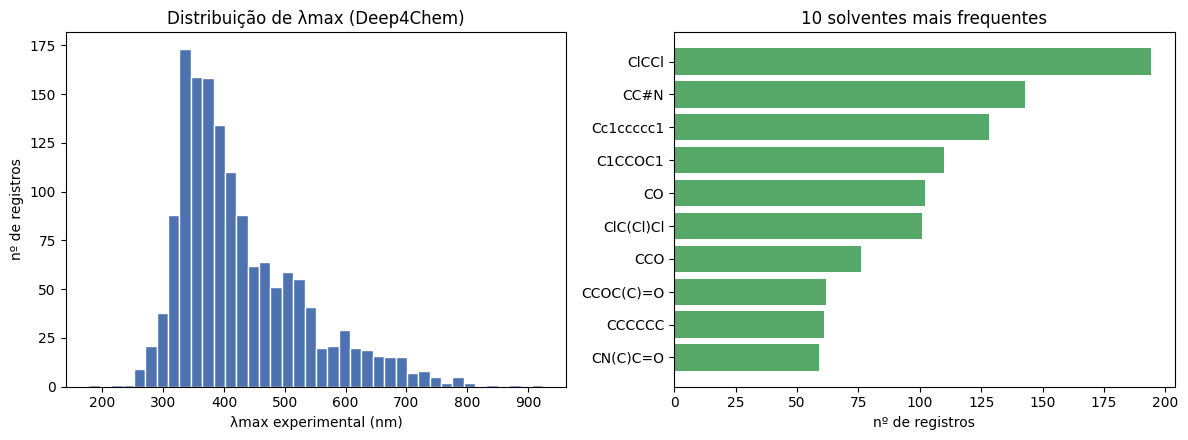

Solvente mais frequente no Deep4Chem (usado como referência na Etapa 2): ClCCl


In [8]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["lambda_max"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("λmax experimental (nm)")
axes[0].set_ylabel("nº de registros")
axes[0].set_title("Distribuição de λmax (Deep4Chem)")

top_solv = df["solvent_smiles"].value_counts().head(10)
axes[1].barh(top_solv.index[::-1], top_solv.values[::-1], color="#55A868")
axes[1].set_xlabel("nº de registros")
axes[1].set_title("10 solventes mais frequentes")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "eda_lambda_solventes.png"), dpi=150)
plt.show()

REFERENCE_SOLVENT = df["solvent_smiles"].value_counts().idxmax()
print("Solvente mais frequente no Deep4Chem (usado como referência na Etapa 2):", REFERENCE_SOLVENT)

## 2. Scaffold split

Split por molécula (arcabouço de Bemis-Murcko), não aleatório: todas as ocorrências de uma mesma
família estrutural (scaffold) do cromóforo ficam inteiramente no treino ou inteiramente no teste.
Isso evita que o mesmo esqueleto molecular apareça nos dois conjuntos, o que superestimaria a
generalização do modelo caso fosse usado um split aleatório.

In [9]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except Exception:
        return smiles


def scaffold_split(frame, test_size=0.2, seed=SEED):
    frame = frame.copy()
    frame["scaffold"] = frame["smiles"].apply(get_scaffold)
    scaffolds = frame["scaffold"].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(scaffolds)
    n_test = max(1, int(len(scaffolds) * test_size))
    test_scaffolds = set(scaffolds[:n_test])
    test_mask = frame["scaffold"].isin(test_scaffolds)
    return frame[~test_mask].reset_index(drop=True), frame[test_mask].reset_index(drop=True)


train_df, test_df = scaffold_split(df, test_size=0.2)
y_train = train_df["lambda_max"].values.astype(np.float32)
y_test = test_df["lambda_max"].values.astype(np.float32)

print("treino:", len(train_df), "| teste:", len(test_df))
print("scaffolds únicos no treino:", train_df["scaffold"].nunique(),
      "| no teste:", test_df["scaffold"].nunique())
print("interseção de scaffolds treino/teste:",
      len(set(train_df["scaffold"]) & set(test_df["scaffold"])), "(deve ser 0)")

treino: 1216 | teste: 284
scaffolds únicos no treino: 684 | no teste: 170
interseção de scaffolds treino/teste: 0 (deve ser 0)


## 3. Features

Fingerprints de Morgan (cromóforo + solvente) para o MLP e a Bi-LSTM, e descritores físico-químicos
do RDKit (cromóforo + solvente) para o Gradient Boosting. O SMILES do **solvente** entra como
feature em todos os modelos, já que λmax é sensível ao ambiente químico (efeito solvatocrômico).

In [10]:
_morgan_gens = {}


def _to_mol(smiles_or_mol):
    # aceita tanto uma string SMILES quanto um Chem.Mol já parseado (útil para o conjunto
    # proprietário, onde parte das moléculas só parseia com o parser tolerante da Etapa 2)
    if isinstance(smiles_or_mol, Chem.Mol):
        return smiles_or_mol
    return Chem.MolFromSmiles(smiles_or_mol)


_morgan_cache = {}


def morgan_fp(smiles_or_mol, n_bits=2048, radius=2):
    # cache por string SMILES: o solvente se repete muito (é constante em toda a Etapa 2 e
    # muito repetido no Deep4Chem), então evitamos recomputar o fingerprint todo dia
    cache_key = (smiles_or_mol, n_bits, radius) if isinstance(smiles_or_mol, str) else None
    if cache_key is not None and cache_key in _morgan_cache:
        return _morgan_cache[cache_key]
    mol = _to_mol(smiles_or_mol)
    key = (radius, n_bits)
    if key not in _morgan_gens:
        _morgan_gens[key] = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = _morgan_gens[key].GetFingerprintAsNumPy(mol).astype(np.float32)
    if cache_key is not None:
        _morgan_cache[cache_key] = fp
    return fp


def build_fp_features(frame, mol_bits=2048, solv_bits=256, mol_col="smiles"):
    X_mol = np.stack(frame[mol_col].apply(lambda m: morgan_fp(m, n_bits=mol_bits)).values)
    X_solv = np.stack(frame["solvent_smiles"].apply(lambda s: morgan_fp(s, n_bits=solv_bits)).values)
    return np.concatenate([X_mol, X_solv], axis=1).astype(np.float32)


_DESC_FUNCS = Descriptors.descList  # lista (nome, função) de ~217 descritores RDKit
_desc_cache = {}


def rdkit_descriptors(smiles_or_mol):
    cache_key = smiles_or_mol if isinstance(smiles_or_mol, str) else None
    if cache_key is not None and cache_key in _desc_cache:
        return _desc_cache[cache_key]
    mol = _to_mol(smiles_or_mol)
    vals = []
    for _, f in _DESC_FUNCS:
        # algumas moléculas do conjunto proprietário só parseiam sem kekulização (ver Etapa 2);
        # um punhado de descritores precisa de estrutura de Kekulé e falha nesses casos —
        # tratamos individualmente em vez de descartar a molécula inteira
        try:
            vals.append(f(mol))
        except Exception:
            vals.append(0.0)
    vals = np.array(vals, dtype=np.float64)
    vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
    # alguns descritores (ex.: Ipc) podem ter magnitude absurda em moléculas grandes;
    # sem esse clip, o cast para float32 estoura (overflow) e gera valores não finitos
    vals = np.clip(vals, -1e6, 1e6)
    vals = vals.astype(np.float32)
    if cache_key is not None:
        _desc_cache[cache_key] = vals
    return vals


def build_descriptor_features(frame, mol_col="smiles"):
    X_mol = np.stack(frame[mol_col].apply(rdkit_descriptors).values)
    X_solv = np.stack(frame["solvent_smiles"].apply(rdkit_descriptors).values)
    return np.concatenate([X_mol, X_solv], axis=1).astype(np.float32)


DESC_NAMES = [f"mol_{n}" for n, _ in _DESC_FUNCS] + [f"solv_{n}" for n, _ in _DESC_FUNCS]
print("dim. fingerprint (mol+solv):", 2048 + 256, "| dim. descritores (mol+solv):", len(DESC_NAMES))

dim. fingerprint (mol+solv): 2304 | dim. descritores (mol+solv): 434


### 3.1. Validação cruzada por scaffold (seleção de hiperparâmetros)

Utilitário comum às Seções 4–6: `GroupKFold` agrupado por scaffold, para que a validação cruzada
respeite a mesma lógica do split externo (nenhum scaffold aparece simultaneamente em treino e
validação de um fold).

In [11]:
def scaffold_group_folds(frame, n_splits=CV_FOLDS):
    gkf = GroupKFold(n_splits=n_splits)
    groups = frame["scaffold"].values
    return list(gkf.split(frame, groups=groups))

## 4. Baseline 1 — MLP + fingerprints Morgan

Referência rápida, interpretável e bem estabelecida na literatura de quimioinformática. Os
fingerprints binários do cromóforo (2.048 bits) e do solvente (256 bits) são concatenados e
alimentam uma rede totalmente conectada.

In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=512, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_train, y_train, X_val, y_val, hidden=512, dropout=0.2,
              epochs=EPOCHS_MLP, lr=1e-3, batch_size=64, verbose=False):
    model = MLP(X_train.shape[1], hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.L1Loss()  # MAE

    ds = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if verbose and (epoch % max(1, epochs // 5) == 0 or epoch == epochs):
            model.eval()
            with torch.no_grad():
                val_mae = mean_absolute_error(y_val, model(X_val_t).cpu().numpy())
            print(f"  epoch {epoch:3d}/{epochs} — val MAE: {val_mae:.2f} nm")
    return model

In [13]:
# Busca de hiperparâmetros (hidden size / dropout) por validação cruzada em grupos de scaffold
mlp_grid = [
    {"hidden": 512, "dropout": 0.2},
    {"hidden": 256, "dropout": 0.3},
]

X_train_fp = build_fp_features(train_df)
X_test_fp = build_fp_features(test_df)

mlp_cv_scores = []
for params in mlp_grid:
    fold_maes = []
    for fold_i, (tr_idx, va_idx) in enumerate(scaffold_group_folds(train_df)):
        model = train_mlp(
            X_train_fp[tr_idx], y_train[tr_idx], X_train_fp[va_idx], y_train[va_idx],
            epochs=EPOCHS_CV, **params,
        )
        model.eval()
        with torch.no_grad():
            pred = model(torch.tensor(X_train_fp[va_idx], dtype=torch.float32).to(device)).cpu().numpy()
        fold_maes.append(mean_absolute_error(y_train[va_idx], pred))
    mean_mae = float(np.mean(fold_maes))
    mlp_cv_scores.append(mean_mae)
    print(params, "-> CV MAE médio:", round(mean_mae, 2), "nm")

best_mlp_params = mlp_grid[int(np.argmin(mlp_cv_scores))]
print("\nMelhores hiperparâmetros do MLP:", best_mlp_params)

{'hidden': 512, 'dropout': 0.2} -> CV MAE médio: 94.4 nm
{'hidden': 256, 'dropout': 0.3} -> CV MAE médio: 97.77 nm

Melhores hiperparâmetros do MLP: {'hidden': 512, 'dropout': 0.2}


In [14]:
# Treino final do MLP com os melhores hiperparâmetros, sobre todo o conjunto de treino
mlp_model = train_mlp(
    X_train_fp, y_train, X_test_fp, y_test,
    epochs=EPOCHS_MLP, verbose=True, **best_mlp_params,
)

mlp_model.eval()
with torch.no_grad():
    mlp_pred = mlp_model(torch.tensor(X_test_fp, dtype=torch.float32).to(device)).cpu().numpy()

print(
    "MLP+Morgan — MAE:", round(mean_absolute_error(y_test, mlp_pred), 2),
    "nm | RMSE:", round(root_mean_squared_error(y_test, mlp_pred), 2), "nm",
)

  epoch   3/15 — val MAE: 85.23 nm
  epoch   6/15 — val MAE: 60.91 nm
  epoch   9/15 — val MAE: 53.97 nm
  epoch  12/15 — val MAE: 53.49 nm
  epoch  15/15 — val MAE: 51.12 nm
MLP+Morgan — MAE: 51.12 nm | RMSE: 70.73 nm


## 5. Baseline 2 (forte) — Gradient Boosting sobre descritores RDKit

`GradientBoostingRegressor` treinado sobre descritores físico-químicos calculados pelo RDKit
(peso molecular, LogP, número de anéis aromáticos, TPSA, entre ~217 descritores), para o
cromóforo e para o solvente — incorporado como comparação adicional sugerida no feedback da
proposta.

In [15]:
X_train_desc = build_descriptor_features(train_df)
X_test_desc = build_descriptor_features(test_df)

gbm_grid = [
    {"max_depth": 3, "learning_rate": 0.1},
    {"max_depth": 4, "learning_rate": 0.05},
]

gbm_cv_scores = []
for params in gbm_grid:
    fold_maes = []
    for tr_idx, va_idx in scaffold_group_folds(train_df):
        gbm_cv = GradientBoostingRegressor(
            n_estimators=GBM_N_ESTIMATORS, random_state=SEED, **params,
        )
        gbm_cv.fit(X_train_desc[tr_idx], y_train[tr_idx])
        pred = gbm_cv.predict(X_train_desc[va_idx])
        fold_maes.append(mean_absolute_error(y_train[va_idx], pred))
    mean_mae = float(np.mean(fold_maes))
    gbm_cv_scores.append(mean_mae)
    print(params, "-> CV MAE médio:", round(mean_mae, 2), "nm")

best_gbm_params = gbm_grid[int(np.argmin(gbm_cv_scores))]
print("\nMelhores hiperparâmetros do GBM:", best_gbm_params)

{'max_depth': 3, 'learning_rate': 0.1} -> CV MAE médio: 48.06 nm
{'max_depth': 4, 'learning_rate': 0.05} -> CV MAE médio: 48.6 nm

Melhores hiperparâmetros do GBM: {'max_depth': 3, 'learning_rate': 0.1}


In [16]:
gbm = GradientBoostingRegressor(
    n_estimators=GBM_N_ESTIMATORS, random_state=SEED, **best_gbm_params,
)
gbm.fit(X_train_desc, y_train)
gbm_pred = gbm.predict(X_test_desc)

print(
    "Gradient Boosting — MAE:", round(mean_absolute_error(y_test, gbm_pred), 2),
    "nm | RMSE:", round(root_mean_squared_error(y_test, gbm_pred), 2), "nm",
)

importances = pd.Series(gbm.feature_importances_, index=DESC_NAMES).sort_values(ascending=False)
print("\nTop 10 descritores mais importantes:")
importances.head(10)

Gradient Boosting — MAE: 44.53 nm | RMSE: 60.52 nm

Top 10 descritores mais importantes:


mol_MaxAbsPartialCharge         0.188917
mol_NumAliphaticHeterocycles    0.079091
mol_fr_allylic_oxid             0.061302
mol_SMR_VSA10                   0.053682
mol_BCUT2D_MRLOW                0.040560
mol_PEOE_VSA8                   0.036730
mol_BertzCT                     0.031358
mol_MinPartialCharge            0.029990
mol_Chi3n                       0.029904
mol_NumAliphaticRings           0.025691
dtype: float64

## 6. Modelo principal — Bi-LSTM char-level sobre SMILES

Cada caractere do SMILES do cromóforo é mapeado a um *embedding* treinável e processado por uma
LSTM bidirecional; a representação final (concatenação dos últimos estados forward/backward) é
concatenada ao fingerprint Morgan do solvente (256 bits) antes de passar por camadas densas que
produzem a predição de λmax.

In [17]:
all_chars = sorted(set("".join(train_df["smiles"].tolist())))
char2idx = {c: i + 1 for i, c in enumerate(all_chars)}  # 0 = padding
vocab_size = len(char2idx) + 1
MAX_LEN = int(train_df["smiles"].str.len().quantile(0.99)) + 2
print("vocabulário:", vocab_size, "caracteres | MAX_LEN:", MAX_LEN)


def encode_smiles(s, max_len=MAX_LEN):
    idxs = [char2idx.get(c, 0) for c in s[:max_len]]
    length = max(len(idxs), 1)
    idxs = idxs + [0] * (max_len - len(idxs))
    return np.array(idxs, dtype=np.int64), length


class SmilesDataset(Dataset):
    def __init__(self, frame, y):
        encoded = frame["smiles"].apply(encode_smiles)
        self.smiles_enc = np.stack(encoded.apply(lambda t: t[0]).values)
        self.lengths = encoded.apply(lambda t: t[1]).values.astype(np.int64)
        self.solv_fp = np.stack(
            frame["solvent_smiles"].apply(lambda s: morgan_fp(s, n_bits=256)).values
        )
        self.y = y.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.smiles_enc[idx],
            self.lengths[idx],
            self.solv_fp[idx],
            self.y[idx],
        )

vocabulário: 42 caracteres | MAX_LEN: 169


In [18]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=128, solv_dim=256, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + solv_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, smiles_idx, lengths, solv_fp):
        emb = self.embedding(smiles_idx)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        h_final = torch.cat([h_n[-2], h_n[-1]], dim=1)  # últimos estados forward + backward
        combined = torch.cat([h_final, solv_fp], dim=1)
        return self.head(combined).squeeze(-1)


def train_bilstm(train_frame, y_tr, val_frame, y_va, emb_dim=64, hidden_dim=128,
                  epochs=EPOCHS_BILSTM, lr=1e-3, batch_size=64, verbose=False):
    model = BiLSTMRegressor(vocab_size, emb_dim=emb_dim, hidden_dim=hidden_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.L1Loss()

    train_ds = SmilesDataset(train_frame, y_tr)
    val_ds = SmilesDataset(val_frame, y_va)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    for epoch in range(1, epochs + 1):
        model.train()
        for smiles_idx, lengths, solv_fp, yb in train_dl:
            smiles_idx, solv_fp, yb = smiles_idx.to(device), solv_fp.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(smiles_idx, lengths, solv_fp), yb)
            loss.backward()
            opt.step()
        if verbose and (epoch % max(1, epochs // 5) == 0 or epoch == epochs):
            model.eval()
            preds, trues = [], []
            with torch.no_grad():
                for smiles_idx, lengths, solv_fp, yb in val_dl:
                    smiles_idx, solv_fp = smiles_idx.to(device), solv_fp.to(device)
                    preds.append(model(smiles_idx, lengths, solv_fp).cpu().numpy())
                    trues.append(yb.numpy())
            val_mae = mean_absolute_error(np.concatenate(trues), np.concatenate(preds))
            print(f"  epoch {epoch:3d}/{epochs} — val MAE: {val_mae:.2f} nm")
    return model


def predict_bilstm(model, frame, y):
    ds = SmilesDataset(frame, y)
    dl = DataLoader(ds, batch_size=128, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for smiles_idx, lengths, solv_fp, _ in dl:
            smiles_idx, solv_fp = smiles_idx.to(device), solv_fp.to(device)
            preds.append(model(smiles_idx, lengths, solv_fp).cpu().numpy())
    return np.concatenate(preds)

In [19]:
# Busca de hiperparâmetros (dimensão do embedding / hidden size da LSTM) por CV em grupos de scaffold
bilstm_grid = [
    {"emb_dim": 64, "hidden_dim": 128},
    {"emb_dim": 32, "hidden_dim": 64},
]

bilstm_cv_scores = []
for params in bilstm_grid:
    fold_maes = []
    for tr_idx, va_idx in scaffold_group_folds(train_df, n_splits=min(CV_FOLDS, 2 if QUICK_TEST else CV_FOLDS)):
        tr_frame, va_frame = train_df.iloc[tr_idx], train_df.iloc[va_idx]
        model = train_bilstm(
            tr_frame, y_train[tr_idx], va_frame, y_train[va_idx],
            epochs=EPOCHS_CV, **params,
        )
        pred = predict_bilstm(model, va_frame, y_train[va_idx])
        fold_maes.append(mean_absolute_error(y_train[va_idx], pred))
    mean_mae = float(np.mean(fold_maes))
    bilstm_cv_scores.append(mean_mae)
    print(params, "-> CV MAE médio:", round(mean_mae, 2), "nm")

best_bilstm_params = bilstm_grid[int(np.argmin(bilstm_cv_scores))]
print("\nMelhores hiperparâmetros da Bi-LSTM:", best_bilstm_params)

{'emb_dim': 64, 'hidden_dim': 128} -> CV MAE médio: 99.51 nm
{'emb_dim': 32, 'hidden_dim': 64} -> CV MAE médio: 92.63 nm

Melhores hiperparâmetros da Bi-LSTM: {'emb_dim': 32, 'hidden_dim': 64}


In [20]:
bilstm_model = train_bilstm(
    train_df, y_train, test_df, y_test,
    epochs=EPOCHS_BILSTM, verbose=True, **best_bilstm_params,
)
bilstm_pred = predict_bilstm(bilstm_model, test_df, y_test)

print(
    "Bi-LSTM — MAE:", round(mean_absolute_error(y_test, bilstm_pred), 2),
    "nm | RMSE:", round(root_mean_squared_error(y_test, bilstm_pred), 2), "nm",
)

  epoch   1/8 — val MAE: 428.64 nm
  epoch   2/8 — val MAE: 314.48 nm
  epoch   3/8 — val MAE: 94.03 nm
  epoch   4/8 — val MAE: 89.68 nm
  epoch   5/8 — val MAE: 82.08 nm
  epoch   6/8 — val MAE: 82.66 nm
  epoch   7/8 — val MAE: 85.04 nm
  epoch   8/8 — val MAE: 81.51 nm
Bi-LSTM — MAE: 81.51 nm | RMSE: 109.8 nm


## 7. (Opcional) Extensão de estado da arte — D-MPNN (Chemprop)

Rede de mensagens direcionadas sobre o grafo molecular [Yang et al., 2019]. Requer
`pip install chemprop`; a célula é auto-guardada e não interrompe o notebook caso a biblioteca
não esteja instalada — deixe para rodar no Colab se houver tempo disponível antes da entrega.

In [21]:
RUN_CHEMPROP = False  # mude para True (com chemprop instalado) para incluir esta comparação

chemprop_results = None
if RUN_CHEMPROP:
    try:
        import chemprop

        train_csv = os.path.join(DATA_DIR, "chemprop_train.csv")
        test_csv = os.path.join(DATA_DIR, "chemprop_test.csv")
        train_df[["smiles", "lambda_max"]].to_csv(train_csv, index=False)
        test_df[["smiles", "lambda_max"]].to_csv(test_csv, index=False)

        save_dir = os.path.join(DATA_DIR, "chemprop_model")
        os.system(
            f"chemprop_train --data_path {train_csv} --separate_test_path {test_csv} "
            f"--dataset_type regression --target_columns lambda_max --smiles_columns smiles "
            f"--metric mae --extra_metrics rmse --save_dir {save_dir} --quiet"
        )
        print("Treino do Chemprop concluído — ver métricas em", save_dir)
    except ImportError:
        print("chemprop não instalado — pulando esta célula (extensão opcional).")
else:
    print("RUN_CHEMPROP=False — extensão opcional não executada nesta rodada.")

RUN_CHEMPROP=False — extensão opcional não executada nesta rodada.


## 8. Comparação de resultados (Etapa 1)

Métricas de teste (scaffold split) para os três modelos obrigatórios, com gráficos exportados em
PNG para inclusão direta no relatório LaTeX (`\includegraphics`).

In [22]:
def report(name, y_true, y_pred):
    return {
        "modelo": name,
        "MAE (nm)": mean_absolute_error(y_true, y_pred),
        "RMSE (nm)": root_mean_squared_error(y_true, y_pred),
    }


results = pd.DataFrame([
    report("MLP + Morgan (baseline)", y_test, mlp_pred),
    report("Gradient Boosting + descritores (baseline forte)", y_test, gbm_pred),
    report("Bi-LSTM + solvente (principal)", y_test, bilstm_pred),
]).sort_values("MAE (nm)").reset_index(drop=True)

results

,modelo,MAE (nm),RMSE (nm)
0,Gradient Boosting + descritores (baseline forte),44.527262,60.515209
1,MLP + Morgan (baseline),51.115345,70.731644
2,Bi-LSTM + solvente (principal),81.508995,109.801559


Melhor modelo na Etapa 1: Gradient Boosting + descritores (baseline forte) | MAE teste: 44.53 nm


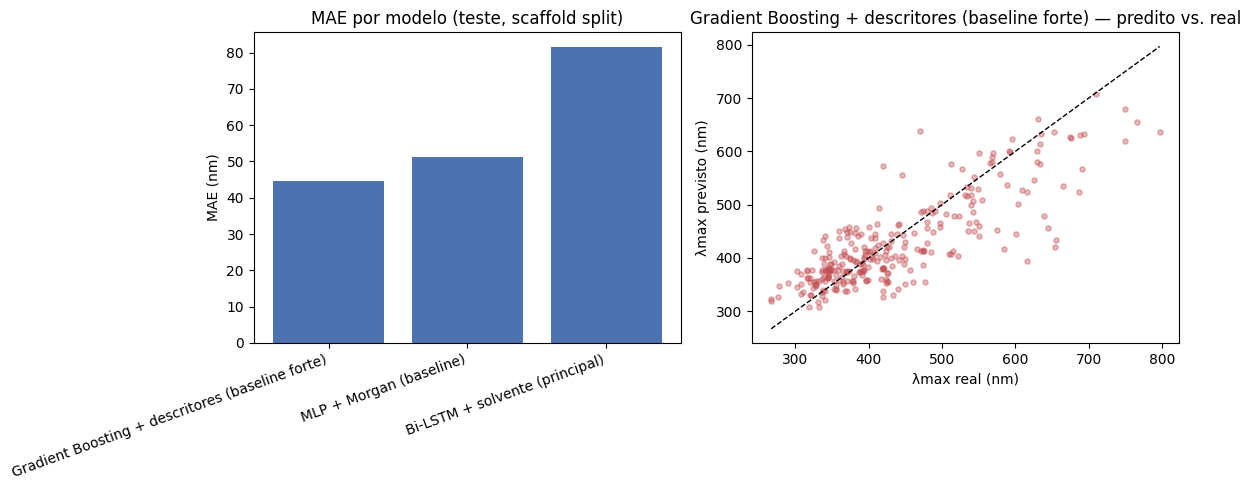

In [23]:
best_row = results.iloc[0]
best_model_name = best_row["modelo"]
print("Melhor modelo na Etapa 1:", best_model_name, "| MAE teste:", round(best_row["MAE (nm)"], 2), "nm")

pred_by_model = {
    "MLP + Morgan (baseline)": mlp_pred,
    "Gradient Boosting + descritores (baseline forte)": gbm_pred,
    "Bi-LSTM + solvente (principal)": bilstm_pred,
}
best_pred = pred_by_model[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results["modelo"], results["MAE (nm)"], color="#4C72B0")
axes[0].set_ylabel("MAE (nm)")
axes[0].set_title("MAE por modelo (teste, scaffold split)")
axes[0].tick_params(axis="x", rotation=20)
for tick in axes[0].get_xticklabels():
    tick.set_ha("right")

axes[1].scatter(y_test, best_pred, alpha=0.4, s=14, color="#C44E52")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("λmax real (nm)")
axes[1].set_ylabel("λmax previsto (nm)")
axes[1].set_title(f"{best_model_name} — predito vs. real")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "comparacao_modelos.png"), dpi=150)
plt.show()

## 9. Etapa 2 — Aplicação no conjunto proprietário (5.974 moléculas)

O melhor modelo da Etapa 1 (`best_model_name`) é aplicado ao conjunto proprietário
(`resources/banco_smiles_aromatizados.parquet`), gerado computacionalmente e sem rótulo de λmax,
para produzir um ranking de candidatos à síntese experimental.

In [24]:
prop_raw = pd.read_parquet(PROP_PATH)

# Colunas de proveniência (rastreiam de quais anéis/fragmentos cada molécula foi montada) —
# mantidas para interpretar o ranking depois e planejar a síntese.
ID_COLS = [c for c in prop_raw.columns if c.lower().startswith("id_")]
SMILES_COL = "smiles"

prop_df = prop_raw[ID_COLS + [SMILES_COL]].copy()
print(prop_df.shape, "moléculas proprietárias | colunas de proveniência:", len(ID_COLS))


def try_parse(smiles):
    '''Parser tolerante: parte do gerador usa ':' explícito entre átomos maiúsculos
    (aromaticidade explícita) em vez de átomos aromáticos minúsculos, o que faz o RDKit falhar
    ao tentar kekulizar. Nesses casos, refazemos o parsing pulando só a etapa de kekulização.'''
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return mol
    mol = Chem.MolFromSmiles(smiles, sanitize=False)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol, sanitizeOps=Chem.SANITIZE_ALL ^ Chem.SANITIZE_KEKULIZE)
        return mol
    except Exception:
        return None


prop_df["mol"] = prop_df[SMILES_COL].apply(try_parse)
n_before = len(prop_df)
prop_df = prop_df[prop_df["mol"].notna()].reset_index(drop=True)
print(f"{len(prop_df)}/{n_before} SMILES parseados com sucesso (parser tolerante a aromaticidade explícita)")

(5974, 12) moléculas proprietárias | colunas de proveniência: 11
5974/5974 SMILES parseados com sucesso (parser tolerante a aromaticidade explícita)


In [ ]:
print("Solvente de referência (constante) usado na Etapa 2:", REFERENCE_SOLVENT)

prop_df["solvent_smiles"] = REFERENCE_SOLVENT

Solvente de referência (constante) usado na Etapa 2: ClCCl


### 9.1. Quantificação de incerteza

Como esse ranking guiará decisões de síntese experimental, priorizamos candidatos de **alta
confiança**: para modelos neurais (MLP/Bi-LSTM), usamos **MC-Dropout** (dropout ativo na
inferência, múltiplas passadas); para o Gradient Boosting, treinamos um pequeno **ensemble
bootstrap** (mesmos hiperparâmetros, sementes/subamostras distintas) — o desvio-padrão entre
passadas/modelos é usado como proxy de incerteza em ambos os casos.

In [26]:
def mc_dropout_mlp(model, X, n_passes=MC_PASSES):
    model.train()  # mantém dropout ativo de propósito
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    passes = []
    with torch.no_grad():
        for _ in range(n_passes):
            passes.append(model(X_t).cpu().numpy())
    passes = np.stack(passes)
    return passes.mean(axis=0), passes.std(axis=0)


def mc_dropout_bilstm(model, frame, n_passes=MC_PASSES):
    model.train()
    dummy_y = np.zeros(len(frame), dtype=np.float32)
    ds = SmilesDataset(frame, dummy_y)
    dl = DataLoader(ds, batch_size=128, shuffle=False)
    all_passes = []
    with torch.no_grad():
        for _ in range(n_passes):
            preds = []
            for smiles_idx, lengths, solv_fp, _ in dl:
                smiles_idx, solv_fp = smiles_idx.to(device), solv_fp.to(device)
                preds.append(model(smiles_idx, lengths, solv_fp).cpu().numpy())
            all_passes.append(np.concatenate(preds))
    all_passes = np.stack(all_passes)
    return all_passes.mean(axis=0), all_passes.std(axis=0)


def gbm_ensemble_uncertainty(X_train, y_train, X_apply, base_params, n_models=GBM_ENSEMBLE_SIZE):
    preds = []
    for i in range(n_models):
        model_i = GradientBoostingRegressor(
            random_state=SEED + i, subsample=0.8, **base_params,
        )
        model_i.fit(X_train, y_train)
        preds.append(model_i.predict(X_apply))
    preds = np.stack(preds)
    return preds.mean(axis=0), preds.std(axis=0)

In [27]:
prop_frame = prop_df.rename(columns={SMILES_COL: "smiles"})

if best_model_name == "Bi-LSTM + solvente (principal)":
    pred_mean, pred_std = mc_dropout_bilstm(bilstm_model, prop_frame)
elif best_model_name == "MLP + Morgan (baseline)":
    X_prop_fp = build_fp_features(prop_frame, mol_col="mol")
    pred_mean, pred_std = mc_dropout_mlp(mlp_model, X_prop_fp)
else:  # Gradient Boosting
    X_prop_desc = build_descriptor_features(prop_frame, mol_col="mol")
    pred_mean, pred_std = gbm_ensemble_uncertainty(
        X_train_desc, y_train, X_prop_desc, {"n_estimators": GBM_N_ESTIMATORS, **best_gbm_params},
    )

ranking = prop_df[ID_COLS + [SMILES_COL]].copy()
ranking["lambda_max_previsto"] = pred_mean
ranking["incerteza_std"] = pred_std
ranking = ranking.sort_values("lambda_max_previsto", ascending=False).reset_index(drop=True)

print(f"Ranking gerado com o modelo '{best_model_name}' (solvente de referência: {REFERENCE_SOLVENT})")
ranking.describe()[["lambda_max_previsto", "incerteza_std"]]

Ranking gerado com o modelo 'Gradient Boosting + descritores (baseline forte)' (solvente de referência: ClCCl)


,lambda_max_previsto,incerteza_std
count,5974.000000,5974.000000
mean,466.415888,21.497060
std,53.179637,7.441010
min,321.805166,2.305669
25%,428.586966,16.272044
50%,464.171859,21.186119
75%,503.227307,26.414747
max,670.020692,51.164145


In [ ]:
# Candidatos prioritários: alto λmax previsto E alta confiança (baixa incerteza)
confianca_thresh = ranking["incerteza_std"].quantile(0.5)  # abaixo da mediana = "alta confiança"
top_confiaveis = (
    ranking[ranking["incerteza_std"] <= confianca_thresh]
    .sort_values("lambda_max_previsto", ascending=False)
    .head(15)
)
print("Top 15 candidatos de alto λmax previsto entre os de maior confiança (incerteza <= mediana):")
top_confiaveis[ID_COLS[:4] + [SMILES_COL, "lambda_max_previsto", "incerteza_std"]]

Top 15 candidatos de alto λmax previsto entre os de maior confiança (incerteza <= mediana):


,id_Anel1,ID_Anel_Anel1,ID_Frag_1_Anel1,ID_Frag_2_Anel1,smiles,lambda_max_previsto,incerteza_std
3,9596,48,21,20,CCC1:C:C(C=CC=CC=CC=CC2C(=C(C#N)C#N)[SH]([O][N...,646.831763,17.674107
11,6441,33,15,17,N#CC(C#N)=C1CC(N)(C=CC=CC=CC=C[SH]2(=C(C#N)C#N...,629.261135,12.368057
13,2645,14,26,25,N=C1:C(=O):C(C=CC=CC=CC=CC2(Br)C(N)CSC2CN(CC(=...,626.569485,8.646418
14,1199,6,5,19,CC(=O)NN1:C:C:C(C=CC=CC=CC2:C:C(=N):C:C(C(=O)[...,626.202691,15.418957
15,3547,18,24,24,CC(=O)NS1:C:C([N+](=O)O):C(C(C)C):C:C:1CC=CC=C...,624.826309,15.033930
30,2660,14,5,20,CCNC1:S:C(NC(C)=O):C:N(C=CC(=O)CC(=O)C=CC2:C:C...,611.683191,17.930037
31,8905,45,5,23,CCNS1:C(Cl):C:C:C(C=CC=CC=CN2NC(S(=O)(=O)[O][N...,611.117097,15.811961
33,67,1,11,25,CCN(CC)C1CN(C(=O)[O][Na])C(N)(C=CC=CC=CC=CC2=C...,610.128572,18.477802
36,427,3,6,22,CCN(CC)C1:C(S(=O)(=O)O):C:C([N+](=O)O):N:C:1C=...,607.071804,14.626035
37,8667,44,10,4,CCOC(=O)C1CC(=C(C#N)C#N)C(C(F)(F)F)N1C=CC=CC=C...,606.709727,12.157444


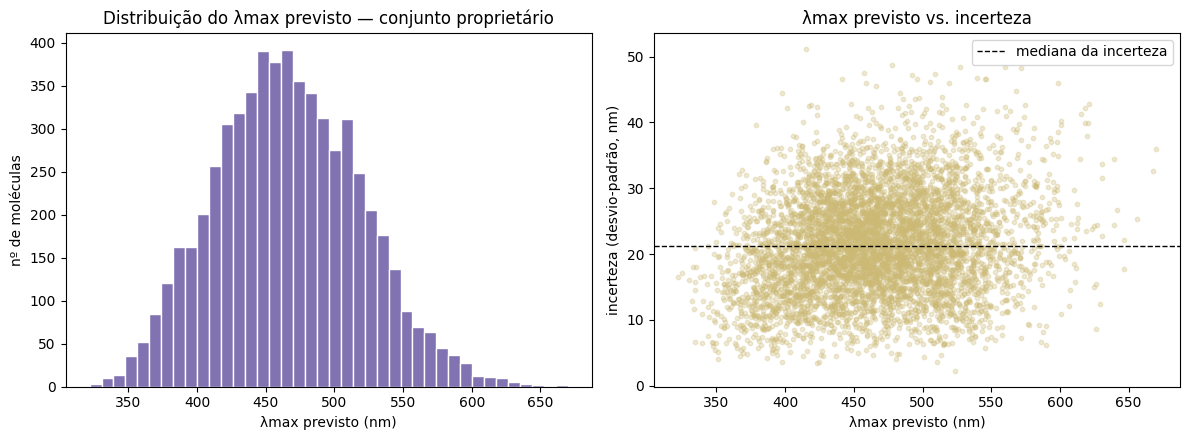

Ranking completo salvo em resources/ranking_lambda_max_proprietario.csv


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(ranking["lambda_max_previsto"], bins=40, color="#8172B2", edgecolor="white")
axes[0].set_xlabel("λmax previsto (nm)")
axes[0].set_ylabel("nº de moléculas")
axes[0].set_title("Distribuição do λmax previsto — conjunto proprietário")

axes[1].scatter(ranking["lambda_max_previsto"], ranking["incerteza_std"], alpha=0.3, s=10, color="#CCB974")
axes[1].axhline(confianca_thresh, color="k", linestyle="--", linewidth=1, label="mediana da incerteza")
axes[1].set_xlabel("λmax previsto (nm)")
axes[1].set_ylabel("incerteza (desvio-padrão, nm)")
axes[1].set_title("λmax previsto vs. incerteza")
axes[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "etapa2_ranking_incerteza.png"), dpi=150)
plt.show()

ranking.to_csv(os.path.join(FIG_DIR, "..", "ranking_lambda_max_proprietario.csv"), index=False)
print("Ranking completo salvo em resources/ranking_lambda_max_proprietario.csv")

### 9.2. Deslocamento de distribuição (domain shift): Deep4Chem vs. conjunto proprietário

Antes de confiar no ranking, avaliamos até que ponto o conjunto proprietário se parece com a
distribuição de treino: comparamos estatísticas de descritores moleculares-chave entre os
cromóforos do Deep4Chem (treino) e as moléculas proprietárias, com teste de Kolmogorov-Smirnov
por descritor (H0: mesma distribuição).

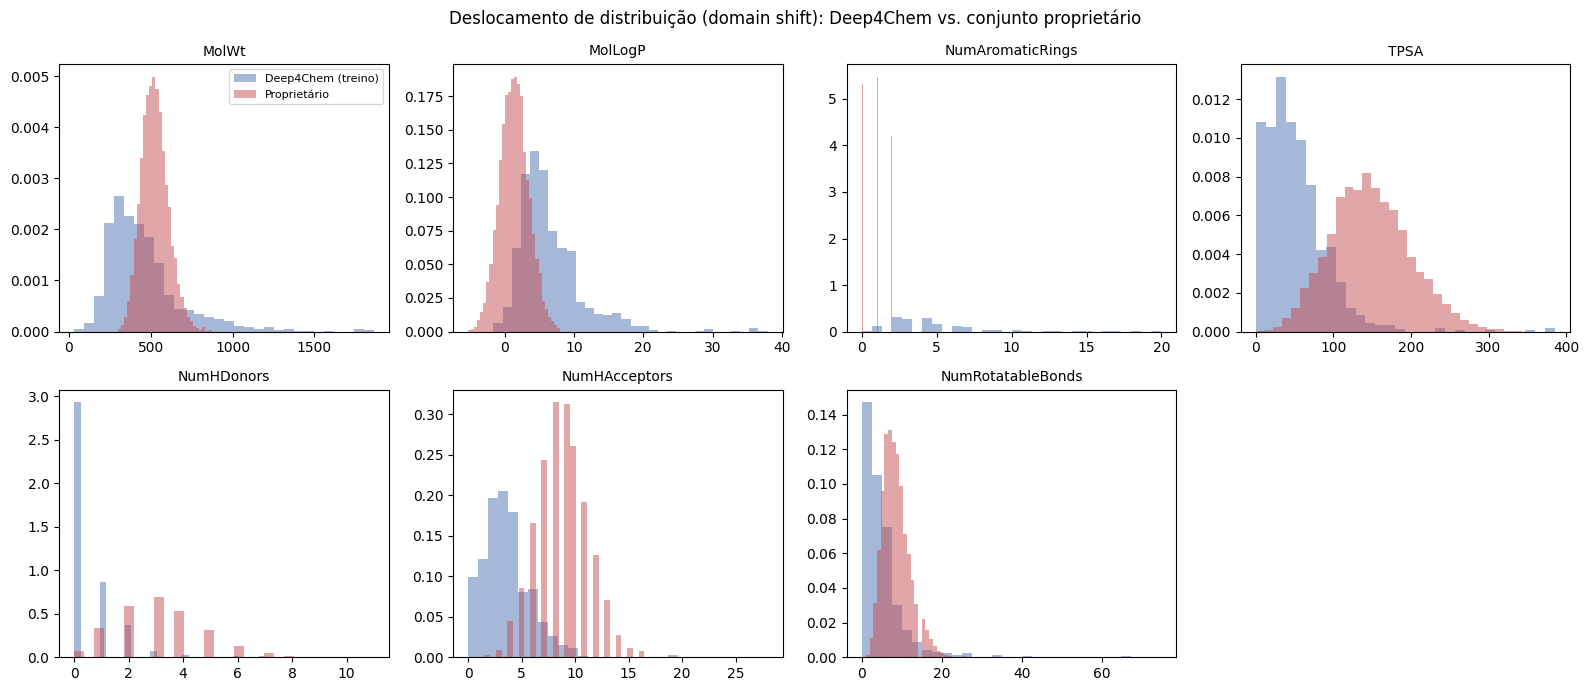

,descritor,media_deep4chem,media_proprietario,KS_stat,KS_pvalue
5,NumHAcceptors,3.446546,8.806160,0.746707,1.294452e-321
3,TPSA,50.349901,148.062591,0.745294,1.304333e-321
4,NumHDonors,0.486020,3.132240,0.736559,1.368562e-321
2,NumAromaticRings,4.209704,0.924506,0.713816,1.709467e-321
1,MolLogP,6.506099,1.394042,0.618297,3.433756e-321
6,NumRotatableBonds,5.097862,8.529126,0.531006,2.045873e-263
0,MolWt,456.149320,524.570172,0.447642,7.968768e-184


In [30]:
from rdkit.Chem import Descriptors as _D

KEY_DESCRIPTORS = {
    "MolWt": _D.MolWt,
    "MolLogP": _D.MolLogP,
    "NumAromaticRings": _D.NumAromaticRings,
    "TPSA": _D.TPSA,
    "NumHDonors": _D.NumHDonors,
    "NumHAcceptors": _D.NumHAcceptors,
    "NumRotatableBonds": _D.NumRotatableBonds,
}

train_mols = train_df["smiles"].apply(Chem.MolFromSmiles)
prop_mols = prop_df["mol"]

shift_rows = []
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, (name, func) in zip(axes, KEY_DESCRIPTORS.items()):
    vals_train = train_mols.apply(func).astype(float).values
    vals_prop = prop_mols.apply(func).astype(float).values
    stat, pval = ks_2samp(vals_train, vals_prop)
    shift_rows.append({
        "descritor": name,
        "media_deep4chem": np.mean(vals_train),
        "media_proprietario": np.mean(vals_prop),
        "KS_stat": stat,
        "KS_pvalue": pval,
    })
    ax.hist(vals_train, bins=30, alpha=0.5, density=True, label="Deep4Chem (treino)", color="#4C72B0")
    ax.hist(vals_prop, bins=30, alpha=0.5, density=True, label="Proprietário", color="#C44E52")
    ax.set_title(name, fontsize=10)
axes[0].legend(fontsize=8)
for ax in axes[len(KEY_DESCRIPTORS):]:
    ax.axis("off")
fig.suptitle("Deslocamento de distribuição (domain shift): Deep4Chem vs. conjunto proprietário")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "domain_shift.png"), dpi=150)
plt.show()

domain_shift_df = pd.DataFrame(shift_rows).sort_values("KS_stat", ascending=False)
domain_shift_df

> **Leitura sugerida para o relatório:** um `KS_stat` alto (próximo de 1) e `KS_pvalue` baixo
> (< 0,05) indicam que a distribuição daquele descritor difere significativamente entre o
> Deep4Chem e o conjunto proprietário — sinal de que a transferência do modelo para essa região
> do espaço químico é menos confiável, e que o ranking deve ser interpretado com mais cautela
> (ou complementado por validação experimental) nesses casos.

## 10. Lições aprendidas e próximos passos

Preencher após a execução completa (QUICK_TEST=False, GPU) com o dataset inteiro — ver Seção 4
("Lições Aprendidas") do relatório SBC:

- **O que funcionou / não funcionou:** comparar o desempenho do scaffold split com um split
  aleatório (célula de controle a adicionar) para quantificar o quanto o scaffold split é mais
  conservador.
- **Ajustes necessários:** confirmar `REFERENCE_SOLVENT` com o laboratório ABC Sim (o solvente
  mais frequente do Deep4Chem pode não ser o de interesse real das amostras proprietárias).
- **Deslocamento de distribuição:** reportar aqui os descritores com maior `KS_stat` da Seção 9.2
  e discutir o impacto na confiabilidade do ranking.
- **Trabalhos futuros:** rodar a extensão Chemprop/D-MPNN (Seção 7) com `RUN_CHEMPROP=True` no
  Colab, e considerar validação cruzada com mais folds (k maior) para os hiperparâmetros finais.